Let's consider multiclass classification of the penguins. We have three classes, this makes a somewhat more interesting classification problem than a simple binary classification.

In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('penguins_size.csv').dropna()
df_train, df_test = train_test_split(df,random_state=1234)
df_train.shape, df_test.shape

((250, 7), (84, 7))

We are going to use all numerical columns as features for a Gaussian Naive Bayesian classifier. The classifier *assumes* all features follow Gaussian distribution (conditioned on the class label), so we can compute the likelihood easily since we know how to deal with normal distributions.

In [88]:
numerical_columns = df_train.columns[2:-1]
X_train = df_train[numerical_columns]
X_test = df_test[numerical_columns]

In [89]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(df_train['species'])
y_test = le.transform(df_test['species'])

In [90]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

Let's see what has happened. We have the following count for the different classes and the following priors.

In [91]:
gnb.class_count_

array([108.,  49.,  93.])

In [92]:
gnb.class_prior_

array([0.432, 0.196, 0.372])

In [93]:
df_train['species'].value_counts()

species
Adelie       108
Gentoo        93
Chinstrap     49
Name: count, dtype: int64

In [94]:
df_train['species'].value_counts()/df_train.shape[0]

species
Adelie       0.432
Gentoo       0.372
Chinstrap    0.196
Name: count, dtype: float64

As expected, these match the species. We can even check that the label encoding matches the permutation of values we saw above.

In [95]:
le.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

Let's predict the class labels for the test set.

In [96]:
y_predicted = gnb.predict(X_test)
y_predicted

array([2, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 2, 1,
       2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 0, 0, 0, 2, 2, 0, 0,
       1, 1, 2, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 2])

We can now compute the confusion matrix (which has shape 3*3). The entry C[i,j] corresponds to having an actual observation of class i being predicted to be from the class j.

In [97]:
import numpy as np
C = np.zeros((3,3))
for (i,j) in zip(y_test,y_predicted):
    C[i,j] += 1

In [98]:
C

array([[37.,  1.,  0.],
       [ 3., 16.,  0.],
       [ 0.,  0., 27.]])

Multiclass accuracy is simply the fraction of correctly classified observations.

In [99]:
np.sum(y_test == y_predicted)/y_test.shape[0]

0.9523809523809523

We can compute the same directly from the confusion matrix by considering the diagonal elements.

In [100]:
acc = C.diagonal().sum()/C.sum()
acc

0.9523809523809523

Precision can be computed on a per-class basis. This is akin to treating this as a binary classification problem with respect to "class i or some other class". As precision relates to everything predicted to be in class i, then precision with respect to class i is the same as summing over the *column* i.

In [101]:
for i in range(3):
    preci = ((y_predicted == i) & (y_test == i)).sum() / (y_predicted == i).sum()
    print(preci)

0.925
0.9411764705882353
1.0


In [102]:
for i in range(3):
    preci = C[i,i] / C[:,i].sum()
    print(preci)

0.925
0.9411764705882353
1.0


Conversely, recall for class i relates to actual class label being i, so we get the values by summing along the rows.

In [103]:
for i in range(3):
    reci = ((y_predicted == i) & (y_test == i)).sum() / (y_test == i).sum()
    print(reci)

0.9736842105263158
0.8421052631578947
1.0


In [104]:
for i in range(3):
    reci = C[i,i] / C[i,:].sum()
    print(reci)

0.9736842105263158
0.8421052631578947
1.0


Finally, let's compute the relative frequency. We'll normalize by dividing by the rowwise sum, that is, C[i,j] will come to represent what fraction of observations actually from class i were classified as being from class j.

In [105]:
C /= C.sum(axis=1)[:,None]
C

array([[0.97368421, 0.02631579, 0.        ],
       [0.15789474, 0.84210526, 0.        ],
       [0.        , 0.        , 1.        ]])

It may make sense to plot the confusion matrix using color. This is also known as a *heat map*, as each element has an intensity associated with the fraction of points predicted to be in that class.

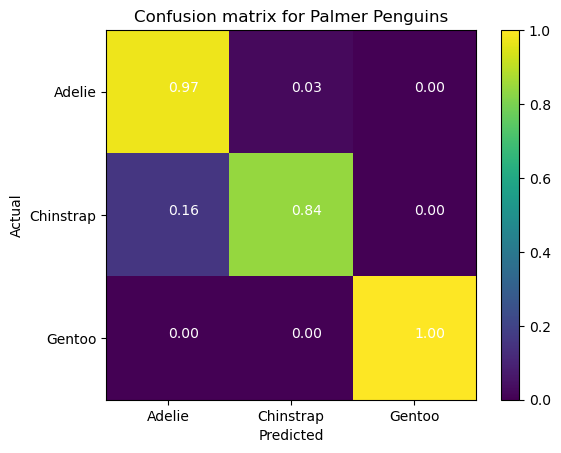

In [106]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
im = ax.imshow(C,cmap='viridis')
ax.set_xticks(np.arange(3),labels=le.classes_)
ax.set_yticks(np.arange(3),labels=le.classes_)
fig.colorbar(im)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{C[i,j]:0.2f}',color='white')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix for Palmer Penguins')
plt.savefig('palmer_confusion_matrix.pdf')